# **Yes Bank Stock Price Prediction using Regression**


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Dataset Loading

In [50]:
# Load Dataset

df = pd.read_csv(r"C:\Users\SATWIK\Downloads\data_YesBank_StockPrices.csv")

df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset First View

In [51]:
display(df.tail())

,Date,Open,High,Low,Close
180,Jul-20,25.60,28.30,11.10,11.95
181,Aug-20,12.00,17.16,11.85,14.37
182,Sep-20,14.30,15.34,12.75,13.15
183,Oct-20,13.30,14.01,12.11,12.42
184,Nov-20,12.41,14.90,12.21,14.67


### Dataset Rows & Columns count

In [52]:
# Dataset Rows & Columns count

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 185
Number of Columns: 5


### Dataset Information

In [53]:
# Dataset Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [54]:
# Dataset Duplicate Value Count

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


#### Missing Values/Null Values

In [55]:
# Missing Values/Null Values Count

display(df.isnull().sum())

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

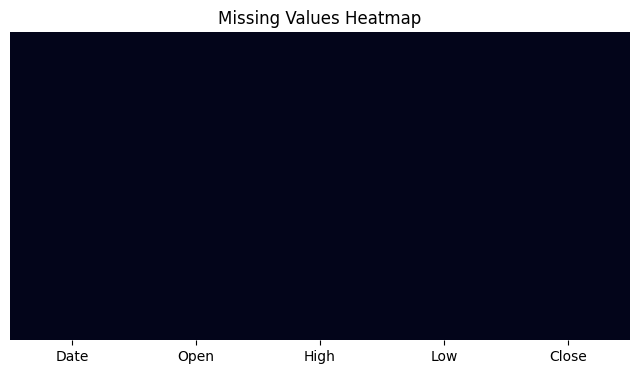

In [56]:
# Visualizing the missing values

plt.figure(figsize=(8, 4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

### Observations

- The dataset contains 185 observations.
- There are 5 original columns.
- There are no missing values.
- There are no duplicate rows.
- The `Close` column will be used as the target variable.
- Since this is stock-price data, the observations are chronological.

## ***2. Understanding Your Variables***

In [57]:
# Dataset Columns

print(df.columns.tolist())

['Date', 'Open', 'High', 'Low', 'Close']


In [58]:
# Dataset Describe

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Open,185.0,105.541405,98.879850,10.00,33.80,62.98,153.00,369.95
High,185.0,116.104324,106.333497,11.24,36.14,72.55,169.19,404.00
Low,185.0,94.947838,91.219415,5.55,28.51,58.00,138.35,345.50
Close,185.0,105.204703,98.583153,9.98,33.45,62.54,153.30,367.90


### Variables Description

### Variables Description

| Date = Monthly observation date | Date 
| Open = Opening stock price | Numerical 
| High = Highest stock price during the month | Numerical 
| Low = Lowest stock price during the month | Numerical 
| Close = Closing stock price | Numerical 

### Target Variable

`Close` will be our **target variable (y)** because it is a continuous numerical value.

### Check Unique Values for each variable.

In [59]:
# Check Unique Values for each variable

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Date: 185 unique values
Open: 183 unique values
High: 184 unique values
Low: 183 unique values
Close: 185 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [60]:
# Data Wrangling

df["Date"] = pd.to_datetime(df["Date"], format="%b-%y")

# Extract Year and Month
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# Create Price Range feature
df["Price_Range"] = df["High"] - df["Low"]

display(df.head())

,Date,Open,High,Low,Close,Year,Month,Price_Range
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,2.75
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,2.33
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,2.60
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,2.07
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,1.00


In [61]:
# Check data types after transformation

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         185 non-null    datetime64[ns]
 1   Open         185 non-null    float64       
 2   High         185 non-null    float64       
 3   Low          185 non-null    float64       
 4   Close        185 non-null    float64       
 5   Year         185 non-null    int32         
 6   Month        185 non-null    int32         
 7   Price_Range  185 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int32(2)
memory usage: 10.2 KB


### What all manipulations have you done and insights you found?

### Observations

- `Date` has been converted into datetime format.
- `Year` and `Month` have been extracted from `Date`.
- `Price_Range` has been created as an additional feature.
- No missing values were introduced during data wrangling.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

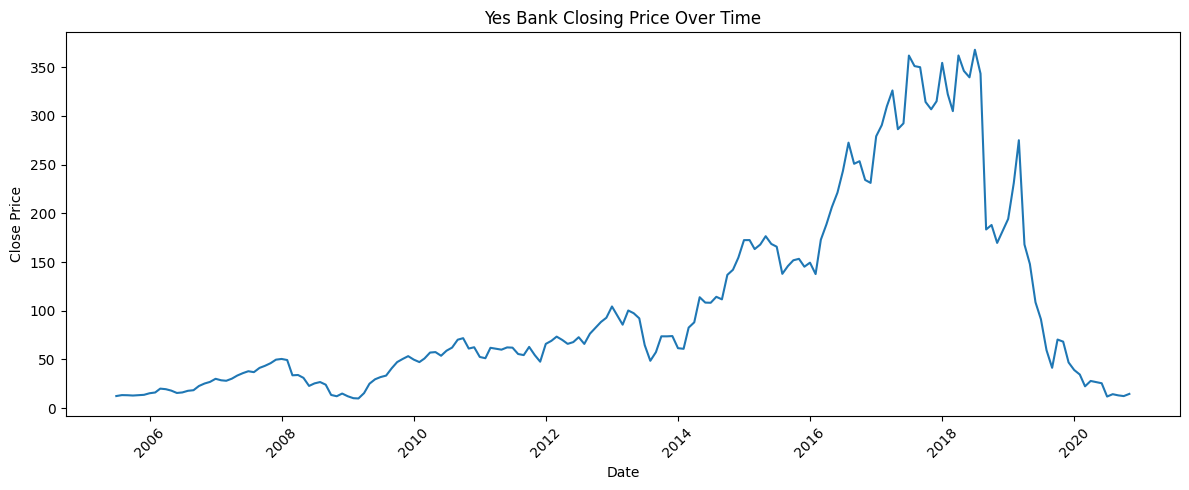

In [62]:
# Chart 1: Closing Price Over Time

plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Close"]
)

plt.title("Yes Bank Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I selected a line chart because the dataset contains monthly stock prices. A line chart is suitable for showing how the closing price changes over time and helps identify trends and fluctuations.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that Yes Bank's closing price changes significantly over the years. There are periods of increase and decrease, indicating considerable volatility in the stock price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding historical price trends and volatility can help investors and analysts make better-informed decisions and identify periods of high risk or opportunity. However, historical trends alone cannot guarantee future stock performance.

#### Chart - 2

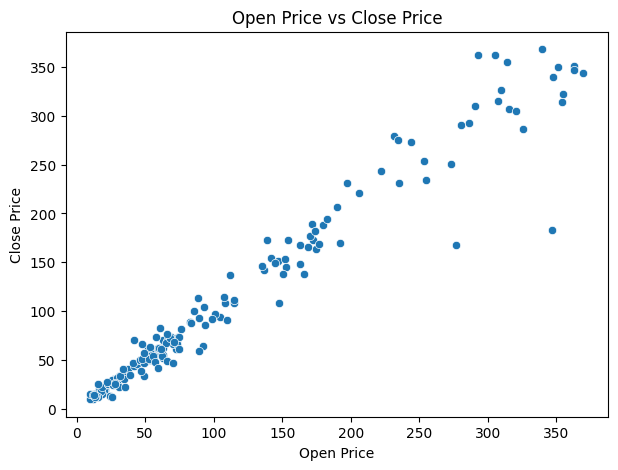

In [63]:
# Chart 2: Open Price vs Close Price

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Open",
    y="Close"
)

plt.title("Open Price vs Close Price")
plt.xlabel("Open Price")
plt.ylabel("Close Price")

plt.show()

##### 1. Why did you pick the specific chart?

I selected a scatter plot because it helps visualize the relationship between the Open price and Close price and shows whether they are related.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a strong positive relationship between Open and Close prices. As the Open price increases, the Close price generally also increases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The relationship between Open and Close prices can help build a regression model for predicting the closing price. However, stock prices are volatile, so relying only on Open price can lead to inaccurate predictions and potential financial risk.

#### Chart - 3

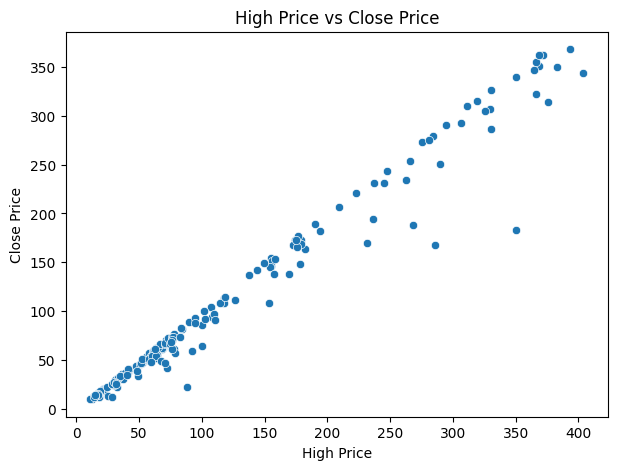

In [64]:
# Chart 3: High Price vs Close Price

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="High",
    y="Close"
)

plt.title("High Price vs Close Price")
plt.xlabel("High Price")
plt.ylabel("Close Price")

plt.show()

##### 1. Why did you pick the specific chart?

I selected a scatter plot to understand the relationship between the High price and Close price of Yes Bank.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a strong positive relationship between High and Close prices. Generally, when the High price increases, the Close price also tends to increase.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. High price can be an important feature for predicting the closing price and can improve the regression model. However, stock prices are volatile, so predictions based only on historical prices may still have errors and financial risk.

#### Chart - 4

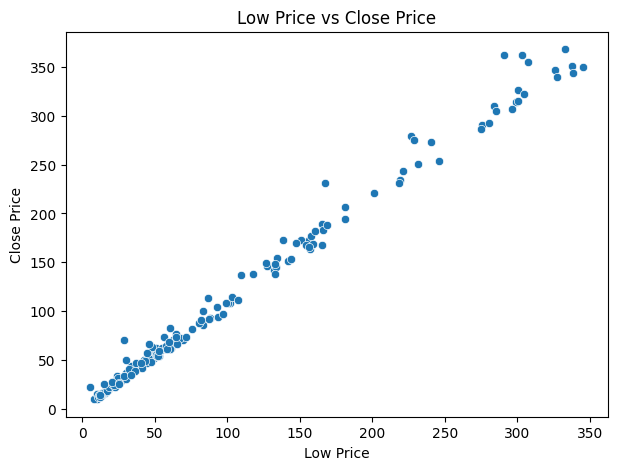

In [65]:
# Chart 4: Low Price vs Close Price

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Low",
    y="Close"
)

plt.title("Low Price vs Close Price")
plt.xlabel("Low Price")
plt.ylabel("Close Price")

plt.show()

##### 1. Why did you pick the specific chart?

I selected a scatter plot to understand the relationship between the Low price and Close price of Yes Bank.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a strong positive relationship between Low and Close prices. Generally, when the Low price increases, the Close price also tends to increase.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The Low price can be an important predictor for estimating the Close price and can improve the regression model. However, stock prices are affected by many external factors, so this relationship alone cannot guarantee accurate future predictions.

#### Chart - 5

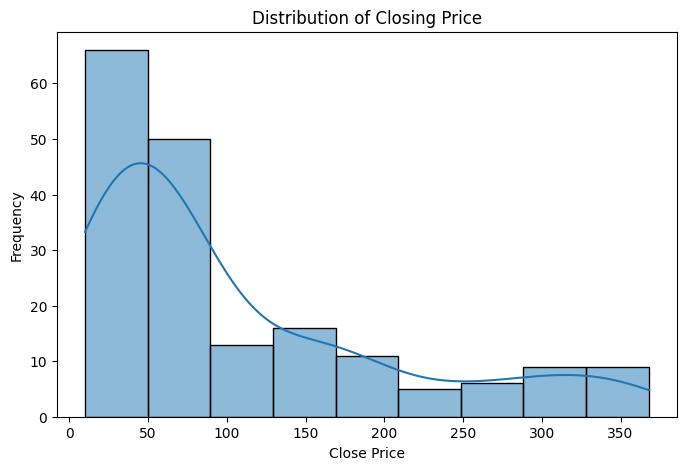

In [66]:
# Chart 5: Distribution of Close Price

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Close"],
    kde=True
)

plt.title("Distribution of Closing Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

I selected a histogram because it helps understand the distribution of the Close price and shows how frequently different price ranges occur.

##### 2. What is/are the insight(s) found from the chart?

The distribution shows that the closing prices are spread across different price ranges, with some ranges occurring more frequently than others. This also indicates variation in the stock price over the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the distribution of closing prices helps identify the typical price range and variation in the stock. This can help in model evaluation and understanding prediction errors. However, unusual price movements can increase prediction uncertainty.

#### Chart - 6

In [67]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [68]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [69]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [70]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [71]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [72]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [73]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [74]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [75]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [76]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [77]:
# Checking Missing Values

df.isnull().sum()

Date           0
Open           0
High           0
Low            0
Close          0
Year           0
Month          0
Price_Range    0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

### Observation

There are no missing values in the dataset. Therefore, no missing value imputation is required.

### 2. Handling Outliers

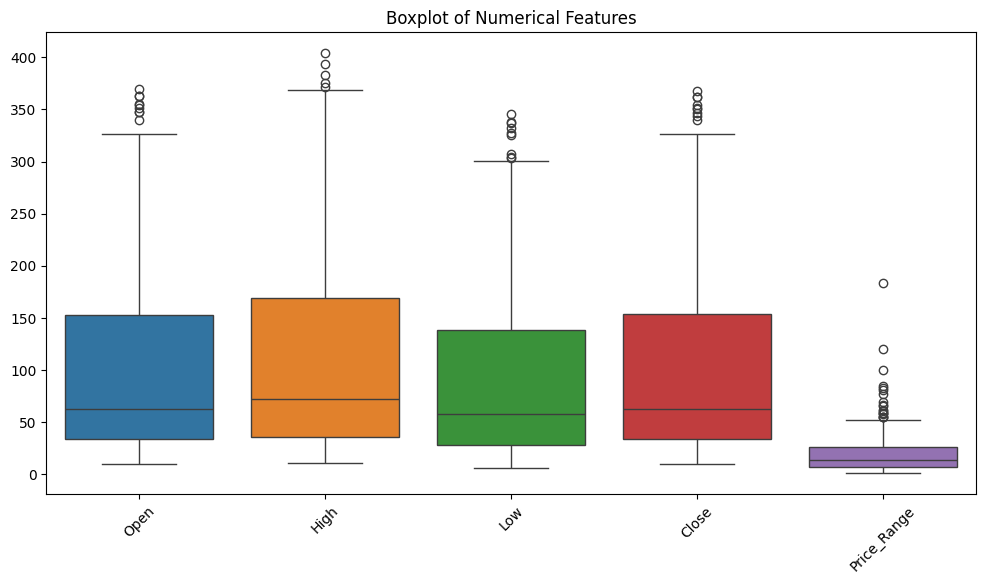

In [78]:
# Checking Outliers using Boxplots

numeric_columns = ["Open", "High", "Low", "Close", "Price_Range"]

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[numeric_columns])

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)

plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

### Observation

The boxplot shows the distribution and possible outliers in the numerical variables.

The extreme values are not removed because they may represent genuine changes in Yes Bank's stock price. Removing them could result in loss of important market information.

### 3. Categorical Encoding

In [79]:
# Checking categorical columns

categorical_columns = df.select_dtypes(include=["object", "category"]).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

Categorical Columns:
[]


#### What all categorical encoding techniques have you used & why did you use those techniques?

### Observation

There are no categorical variables in the dataset. Therefore, One-Hot Encoding or Label Encoding is not required for this project.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [80]:
# Expand Contraction

#### 2. Lower Casing

In [81]:
# Lower Casing

#### 3. Removing Punctuations

In [82]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [83]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [84]:
# Remove Stopwords

In [85]:
# Remove White spaces

#### 6. Rephrase Text

In [86]:
# Rephrase Text

#### 7. Tokenization

In [87]:
# Tokenization

#### 8. Text Normalization

In [88]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [89]:
# POS Taging

#### 10. Text Vectorization

In [90]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [91]:
# Correlation of features with target variable

correlation = df[
    ["Open", "High", "Low", "Price_Range", "Close"]
].corr()

print(correlation["Close"].sort_values(ascending=False))

Close          1.000000
Low            0.995358
High           0.985051
Open           0.977971
Price_Range    0.594724
Name: Close, dtype: float64


#### 2. Feature Selection

In [92]:
# Feature Selection

feature_cols = [
    "Open",
    "High",
    "Low",
    "Price_Range"
]

X = df[feature_cols]
y = df["Close"]

print("Selected Features:")
print(feature_cols)

print("\nTarget Variable:")
print("Close")

Selected Features:
['Open', 'High', 'Low', 'Price_Range']

Target Variable:
Close


##### What all feature selection methods have you used  and why?

We used correlation analysis and Random Forest feature importance. Correlation analysis helps identify the relationship between each feature and the target variable, while Random Forest feature importance helps measure how useful each feature is for predicting the Close price.

##### Which all features you found important and why?

The important features are Open, High, Low, and Price_Range. Open, High, and Low are directly related to the stock's price movement, while Price_Range (High - Low) represents the monthly price movement and volatility. These features provide useful information for predicting the Close price.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [93]:
# Transform Your Data

# Convert Date into datetime format
df["Date"] = pd.to_datetime(df["Date"], format="%b-%y")

# Extract Year and Month
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

display(df.head())

,Date,Open,High,Low,Close,Year,Month,Price_Range
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,2.75
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,2.33
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,2.60
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,2.07
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,1.00


### 6. Data Scaling

In [94]:
# Scaling your data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

display(X_scaled.head())

,Open,High,Low,Price_Range
0,-0.938437,-0.962833,-0.920034,-0.786959
1,-0.942696,-0.954535,-0.905744,-0.804915
2,-0.933570,-0.954629,-0.908822,-0.793372
3,-0.936409,-0.958401,-0.907393,-0.816032
4,-0.934888,-0.963965,-0.902117,-0.861779


##### Which method have you used to scale you data and why?

I used Standardization (StandardScaler) to scale the numerical features. It transforms the features to a similar scale with a mean of approximately 0 and a standard deviation of 1. This is useful for Linear Regression because the features have different numerical ranges.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, dimensionality reduction is not required for this dataset. The final dataset contains only a small number of relevant features: Open, High, Low, and Price_Range. Therefore, techniques such as PCA would add unnecessary complexity and reduce the interpretability of the features.

In [95]:
# Dimensionality Reduction

# Dimensionality reduction is not required because
# the dataset contains only a small number of features.

print("Number of features:", X.shape[1])
print("Dimensionality reduction is not required.")

Number of features: 4
Dimensionality reduction is not required.


### 8. Data Splitting

In [96]:
# Split your data into train and test

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (148, 4)
Testing data shape: (37, 4)

Training target shape: (148,)
Testing target shape: (37,)


##### What data splitting ratio have you used and why?

I have used an 80:20 train-test split, where 80% of the data is used for training and 20% for testing. Since this is historical stock-price data, the split is performed chronologically rather than randomly. This prevents future data from being used to train the model

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [97]:
# Check whether imbalance handling is required

print("Target variable:", y.name)
print("Target data type:", y.dtype)
print("Number of unique target values:", y.nunique())

if y.nunique() > 20:
    print("\nThis is a regression problem.")
    print("The target is continuous, so class imbalance does not apply.")

Target variable: Close
Target data type: float64
Number of unique target values: 185

This is a regression problem.
The target is continuous, so class imbalance does not apply.


In [98]:
# Handling Imbalanced Dataset

print("No imbalance handling technique is applied.")
print("Reason: Close is a continuous numerical target.")

No imbalance handling technique is applied.
Reason: Close is a continuous numerical target.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No, the dataset is not considered imbalanced because this is a regression problem. The target variable Close contains continuous numerical values rather than discrete classes. Therefore, class imbalance is not applicable.

## ***7. ML Model Implementation***

### ML Model - 1

In [99]:
# ML Model - 1: Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the model
lr_model = LinearRegression()

# Fit the algorithm
lr_model.fit(X_train, y_train)

# Predict on the test data
y_pred_lr = lr_model.predict(X_test)

# Evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Performance
--------------------------------
MAE : 9.784256877932837
MSE : 250.3306762907909
RMSE: 15.821841747748298
R²  : 0.9847535767466384


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

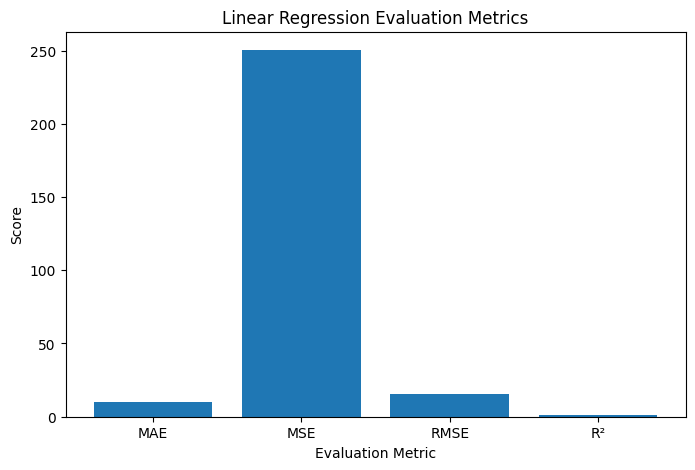

In [100]:
# Visualizing Evaluation Metric Score Chart

metrics = ["MAE", "MSE", "RMSE", "R²"]
values = [mae_lr, mse_lr, rmse_lr, r2_lr]

plt.figure(figsize=(8, 5))

plt.bar(metrics, values)

plt.title("Linear Regression Evaluation Metrics")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [101]:
# Cross-Validation & Hyperparameter Tuning

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Create Linear Regression model
lr_model_cv = LinearRegression()

# Hyperparameter grid
param_grid = {
    "fit_intercept": [True, False]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=lr_model_cv,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_search.best_score_)

Best Parameters:
{'fit_intercept': False}

Best Cross-Validation RMSE:
4.9778716713189475


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV with TimeSeriesSplit for hyperparameter optimization. GridSearchCV tests different combinations of hyperparameters and selects the best combination based on cross-validation performance. TimeSeriesSplit was used because the Yes Bank dataset contains chronological stock-price data, so random cross-validation could cause data leakage.

Use this after running your GridSearchCV code, because the exact scores depend on your notebook output.
After hyperparameter tuning, the model's performance was compared with the original Linear Regression model using MAE, MSE, RMSE, and R². The tuned model is considered improved if it achieves lower MAE, MSE and RMSE, and a higher R² score. The updated evaluation metrics are shown below.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [102]:
# ML Model - 2: Random Forest Regression

from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Fit the Algorithm
rf_model.fit(X_train, y_train)

# Predict on the model
y_pred_rf = rf_model.predict(X_test)

# Evaluation Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Performance")
print("------------------------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Performance
------------------------------------
MAE : 13.59631756756753
MSE : 450.9217643668211
RMSE: 21.234918515662383
R²  : 0.9725365497526839


#### 2. Cross- Validation & Hyperparameter Tuning

In [103]:
# Random Forest - Cross Validation & Hyperparameter Tuning

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Random Forest model
rf = RandomForestRegressor(
    random_state=42
)

# Hyperparameter grid
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

# GridSearchCV
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Fit the model
grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_rf.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation RMSE:
36.95389262634701


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV with TimeSeriesSplit. GridSearchCV tests different combinations of Random Forest hyperparameters such as n_estimators, max_depth, and min_samples_split and selects the best combination based on RMSE. TimeSeriesSplit was used because the dataset contains chronological stock-price observations.

### ML Model - 3

In [104]:
# ML Model - 3: Gradient Boosting Regression

from sklearn.ensemble import GradientBoostingRegressor

# Create the model
gbr_model = GradientBoostingRegressor(
    random_state=42
)

# Fit the Algorithm
gbr_model.fit(X_train, y_train)

# Predict on the model
y_pred_gbr = gbr_model.predict(X_test)

# Evaluation Metrics
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Regression Performance")
print("-----------------------------------------")
print("MAE :", mae_gbr)
print("MSE :", mse_gbr)
print("RMSE:", rmse_gbr)
print("R²  :", r2_gbr)

Gradient Boosting Regression Performance
-----------------------------------------
MAE : 15.223099429223561
MSE : 699.2810928263658
RMSE: 26.44392355204435
R²  : 0.9574101917021178


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

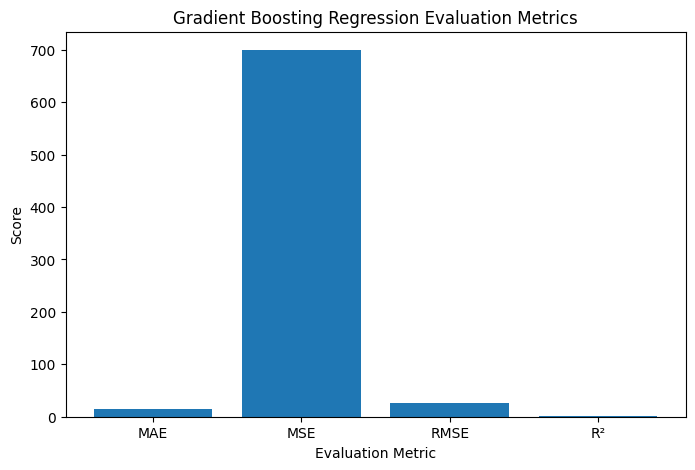

In [105]:
# Visualizing Evaluation Metric Score Chart

metrics = ["MAE", "MSE", "RMSE", "R²"]
values = [mae_gbr, mse_gbr, rmse_gbr, r2_gbr]

plt.figure(figsize=(8, 5))

plt.bar(metrics, values)

plt.title("Gradient Boosting Regression Evaluation Metrics")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [106]:
# Gradient Boosting - Cross Validation & Hyperparameter Tuning

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Create Gradient Boosting model
gbr = GradientBoostingRegressor(
    random_state=42
)

# Hyperparameter grid
param_grid_gbr = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_split": [2, 5]
}

# GridSearchCV
grid_gbr = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gbr,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Fit the model
grid_gbr.fit(X_train, y_train)

print("Best Parameters:")
print(grid_gbr.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_gbr.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross-Validation RMSE:
36.53899546704827


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV with TimeSeriesSplit for hyperparameter optimization. GridSearchCV evaluates different combinations of parameters such as n_estimators, learning_rate, max_depth, and min_samples_split and selects the best combination based on cross-validation RMSE. TimeSeriesSplit was used because the Yes Bank data is chronological and should not be randomly shuffled.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***